# Movie Recommendation System Pipeline

This notebook acts as the orchestrator to train, evaluate, and demonstrate the SequenceRecommender logic.

In [4]:
import torch
import torch.nn as nn
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from dataset import load_data, process_data, collate_fn, MovieSequenceDataset
from model import SequenceRecommender
from train import train_with_oom_fallback
from evaluate import evaluate_model
from torch.utils.data import DataLoader

plt.style.use('ggplot')

# Fix seeds globally for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)


Using device: cuda


## 1. Load Data

In [5]:
# Load and process data enforcing chronological splits & avoiding arbitrary leakage
ratings_df, movies_df = load_data('data')
train_data, val_data, test_data, movie2idx, user2idx = process_data(ratings_df, max_seq_len=50)

print(f"Num Train pairs: {len(train_data)}")
print(f"Num Val pairs: {len(val_data)}")
print(f"Num Test pairs: {len(test_data)}")

train_dataset = MovieSequenceDataset(train_data)
val_dataset = MovieSequenceDataset(val_data)
test_dataset = MovieSequenceDataset(test_data)

num_users = len(user2idx)
num_movies = len(movie2idx) + 1  # 0 acts as default zero padding idx reserve

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, collate_fn=collate_fn)


Num Train pairs: 791718
Num Val pairs: 93652
Num Test pairs: 96719


In [6]:
import os
import torch
import pandas as pd

CACHE_FILE = 'training_cache.pt'
SKIP_TRAINING = os.path.exists(CACHE_FILE)

if SKIP_TRAINING:
    print("✅ Phát hiện dữ liệu đã huấn luyện từ trước! Tự động bỏ qua bước train.")
    cache = torch.load(CACHE_FILE, map_location=device)
    results_arch = cache['results_arch']
    results_opt = cache['results_opt']
    # Replay saved epoch outputs so users still see epoch logs when running the whole notebook
    def _replay_epochs(name, train_losses, val_losses):
        if not train_losses and not val_losses:
            return
        total = max(len(train_losses), len(val_losses))
        for e in range(total):
            tr = train_losses[e] if e < len(train_losses) else float('nan')
            va = val_losses[e] if e < len(val_losses) else float('nan')
            try:
                print(f"[{name}] Epoch {e+1}/{total} - Train Loss: {tr:.4f}  Val Loss: {va:.4f}")
            except Exception:
                print(f"[{name}] Epoch {e+1}/{total} - Train Loss: {tr}  Val Loss: {va}")
    print('\n✅ Replaying saved training epochs from cache...')
    if 'results_arch' in locals():
        for arch, res in results_arch.items():
            _replay_epochs(f'ARCH-{arch.upper()}', res.get('train_losses', []), res.get('val_losses', []))
    if 'results_opt' in locals():
        for exp, res in results_opt.items():
            _replay_epochs(f'OPT-{exp}', res.get('train_losses', []), res.get('val_losses', []))


✅ Phát hiện dữ liệu đã huấn luyện từ trước! Tự động bỏ qua bước train.

✅ Replaying saved training epochs from cache...
[ARCH-RNN] Epoch 1/10 - Train Loss: 6.8835  Val Loss: 6.7564
[ARCH-RNN] Epoch 2/10 - Train Loss: 6.2208  Val Loss: 6.5384
[ARCH-RNN] Epoch 3/10 - Train Loss: 6.0546  Val Loss: 6.5411
[ARCH-RNN] Epoch 4/10 - Train Loss: 5.9695  Val Loss: 6.4147
[ARCH-RNN] Epoch 5/10 - Train Loss: 5.9071  Val Loss: 6.3845
[ARCH-RNN] Epoch 6/10 - Train Loss: 5.8632  Val Loss: 6.3758
[ARCH-RNN] Epoch 7/10 - Train Loss: 5.8416  Val Loss: 6.3639
[ARCH-RNN] Epoch 8/10 - Train Loss: 5.8138  Val Loss: 6.3497
[ARCH-RNN] Epoch 9/10 - Train Loss: 5.7812  Val Loss: 6.3535
[ARCH-RNN] Epoch 10/10 - Train Loss: 5.7709  Val Loss: 6.3397
[ARCH-LSTM] Epoch 1/10 - Train Loss: 6.7344  Val Loss: 6.6567
[ARCH-LSTM] Epoch 2/10 - Train Loss: 5.9900  Val Loss: 6.4356
[ARCH-LSTM] Epoch 3/10 - Train Loss: 5.7842  Val Loss: 6.3599
[ARCH-LSTM] Epoch 4/10 - Train Loss: 5.6785  Val Loss: 6.3597
[ARCH-LSTM] Epoch 5/1

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12800\332413756.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cache = torch.load(CACHE_FILE, map_location=device)


if not SKIP_TRAINING:
    ## 2. Architecture Comparison (RNN vs LSTM vs GRU)
    Looping over models using general learning parameters.

In [8]:
if not SKIP_TRAINING:
    architectures = ['rnn', 'lstm', 'gru']
    results_arch = {}
    
    for arch in architectures:
        print(f"\n--- Training {arch.upper()} ---")
        create_model_fn = lambda a=arch: SequenceRecommender(
            num_users=num_users, 
            num_movies=num_movies, 
            rnn_type=a
        )
        
        # Train executing with batch reducing try/except bounds explicitly enabled
        model, train_losses, val_losses, final_batch_size = train_with_oom_fallback(
            create_model_fn, train_dataset, val_dataset, 
            optimizer_name='adam', lr=1e-3, num_epochs=10, 
            device=device, start_batch_size=256
        )
        
        # Evaluate strictly upon target set limits
        top1, hr10 = evaluate_model(model, test_loader, device=device)
        print(f"Test Top-1 Acc: {top1:.4f}, Test HR@10: {hr10:.4f}")
        
        results_arch[arch] = {
            'model': model,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'top1': top1,
            'hr10': hr10
        }


### Architecture Comparison Results

,Architecture,Top-1 Acc,HR@10
0,RNN,0.023594,0.129364
1,LSTM,0.020896,0.114972
2,GRU,0.023067,0.117857


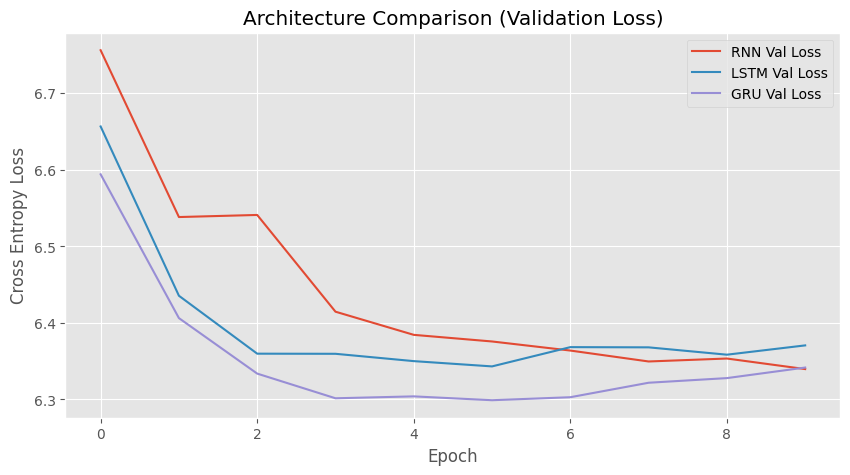

Best Architecture Selected: RNN


In [9]:
arch_summary = []
for arch, res in results_arch.items():
    arch_summary.append({
        'Architecture': arch.upper(),
        'Top-1 Acc': res['top1'],
        'HR@10': res['hr10']
    })
df_arch = pd.DataFrame(arch_summary)
display(df_arch)

# Plot Loss Curves Mapping
plt.figure(figsize=(10, 5))
for arch, res in results_arch.items():
    plt.plot(res['val_losses'], label=f"{arch.upper()} Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Architecture Comparison (Validation Loss)")
plt.legend()
plt.show()

# Selecting architecture
best_arch = df_arch.sort_values(by='HR@10', ascending=False).iloc[0]['Architecture'].lower()
print(f"Best Architecture Selected: {best_arch.upper()}")


if not SKIP_TRAINING:
    ## 3. Optimizer & LR Tuning (SGD vs Adam)
    Using the best backbone architecture found prior.

In [10]:
if not SKIP_TRAINING:
    optimizers = ['sgd', 'adam']
    learning_rates = [1e-2, 1e-3, 1e-4]
    results_opt = {}
    
    print(f"Tuning optimizers mapping explicitly down through {best_arch.upper()}...")
    
    for opt in optimizers:
        for lr in learning_rates:
            exp_name = f"{opt.upper()}_lr{lr}"
            print(f"\n--- Experiment: {exp_name} ---")
            
            create_model_fn = lambda o=opt: SequenceRecommender(
                num_users=num_users, 
                num_movies=num_movies, 
                rnn_type=best_arch
            )
            
            model, train_losses, val_losses, _ = train_with_oom_fallback(
                create_model_fn, train_dataset, val_dataset, 
                optimizer_name=opt, lr=lr, num_epochs=10, 
                device=device, start_batch_size=256
            )
            
            top1, hr10 = evaluate_model(model, test_loader, device=device)
            
            results_opt[exp_name] = {
                'model': model,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'top1': top1,
                'hr10': hr10,
                'opt': opt,
                'lr': lr
            }


### Optimizer Comparison Results

if not SKIP_TRAINING:
    print("\nLưu dữ liệu huấn luyện vào ổ cứng để chạy nhanh lần sau...")
    torch.save({'results_arch': results_arch, 'results_opt': results_opt}, CACHE_FILE)


,Optimizer,Learning Rate,Top-1 Acc,HR@10
0,SGD,0.0100,0.001789,0.014465
1,SGD,0.0010,0.001055,0.008520
2,SGD,0.0001,0.000331,0.002885
3,ADAM,0.0100,0.003732,0.020761
4,ADAM,0.0010,0.023025,0.123595
5,ADAM,0.0001,0.012945,0.073098


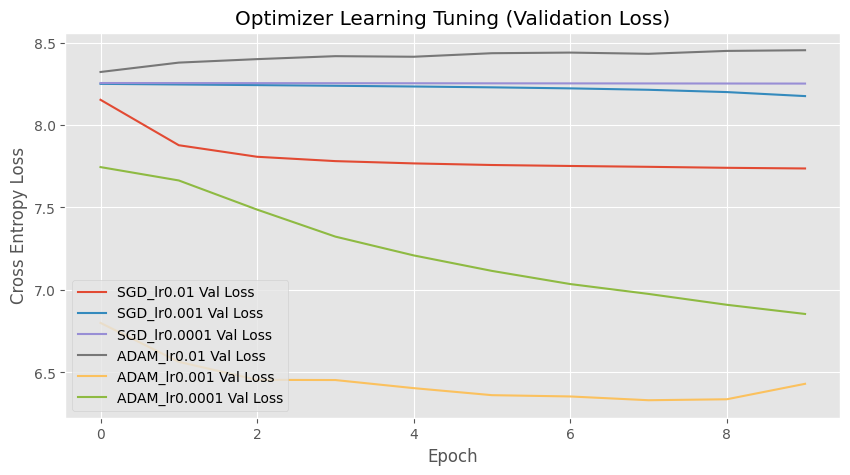

Winning Optimization Approach: ADAM_lr0.001


In [11]:
opt_summary = []
for exp_name, res in results_opt.items():
    opt_summary.append({
        'Optimizer': res['opt'].upper(),
        'Learning Rate': res['lr'],
        'Top-1 Acc': res['top1'],
        'HR@10': res['hr10']
    })
df_opt = pd.DataFrame(opt_summary)
display(df_opt)

plt.figure(figsize=(10, 5))
for exp_name, res in results_opt.items():
    plt.plot(res['val_losses'], label=f"{exp_name} Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Optimizer Learning Tuning (Validation Loss)")
plt.legend()
plt.show()

# Store mapping pointer into actual best
best_exp_row = df_opt.sort_values(by='HR@10', ascending=False).iloc[0]
best_exp_name = f"{best_exp_row['Optimizer']}_lr{best_exp_row['Learning Rate']}"
best_model = results_opt[best_exp_name]['model']
print(f"Winning Optimization Approach: {best_exp_name}")

if not SKIP_TRAINING:
    print("\nLưu dữ liệu huấn luyện vào ổ cứng để chạy nhanh lần sau...")
    torch.save({'results_arch': results_arch, 'results_opt': results_opt}, CACHE_FILE)


## 4. Interactive Recommendation Demo

In [12]:
import re

def normalize_title(title):
    title = title.lower().strip()
    # Scrape trailing yearly indicators mapping string matches e.g., (1998)
    title = re.sub(r'\(\d{4}\)', '', title).strip()
    return title

# Prep database identifiers dictionary maps
movies_df['normalized_title'] = movies_df['title'].apply(normalize_title)
idx2movie = {idx: mid for mid, idx in movie2idx.items()}
mid2title = dict(zip(movies_df['movie_id'], movies_df['title']))

def predict_next_movie(input_titles, model):
    model.eval()
    
    movie_indices = []
    found_titles = []
    
    for t in input_titles:
        norm_t = normalize_title(t)
        match = movies_df[movies_df['normalized_title'].str.contains(norm_t, regex=False, na=False)]
        
        if not match.empty:
            best_match_id = match.iloc[0]['movie_id']
            if best_match_id in movie2idx:
                movie_indices.append(movie2idx[best_match_id])
                found_titles.append(match.iloc[0]['title'])
            else:
                print(f"Movie {norm_t} id not mapped in training set split.")
        else:
            print(f"Could not find match for '{t}' in dataset.")
            
    if not movie_indices:
        print("No valid movies found to build a recommendation sequence.")
        return
        
    print(f"Mapped Input Sequence Context: {found_titles}")
    
    seq_tensor = torch.tensor([movie_indices], dtype=torch.long).to(device)
    # Using User 0 explicitly as generic cold-pass inference block required by design limits
    user_tensor = torch.tensor([0], dtype=torch.long).to(device)
    lengths_tensor = torch.tensor([len(movie_indices)], dtype=torch.long).to(device)
    
    with torch.no_grad():
        probs = model.predict(user_tensor, seq_tensor, lengths_tensor)
        
    probs[0, 0] = -1.0 # Negate 0 padding collision chance
    
    # Isolate absolute max probabilistic ID dimension.
    pred_idx = probs.argmax(dim=-1).item()
    
    if pred_idx in idx2movie:
        pred_mid = idx2movie[pred_idx]
        print(f"\n---> RECOMMENDED NEXT ITEM: {mid2title.get(pred_mid, 'Unknown')} <---")
    else:
        print("Model predicted unrecognized parameter bounds.")

# Run User Input test block explicitly
# input_history = ["Titanic", "Avatar", "Inception"]
# predict_next_movie(input_history, best_model)


In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Lấy danh sách tên phim từ DataFrame để làm gợi ý tìm kiếm (autocomplete)
all_titles = movies_df['title'].dropna().unique().tolist()

# 1. Khởi tạo các thành phần giao diện (UI)
movie_input = widgets.Combobox(
    placeholder='Gõ tên phim (VD: Toy Story)',
    options=all_titles,
    description='Tìm phim:',
    ensure_option=False,
    disabled=False,
    layout=widgets.Layout(width='400px')
)

add_button = widgets.Button(description='Thêm vào lịch sử', button_style='info', icon='plus')
predict_button = widgets.Button(description='Dự đoán phim mới', button_style='success', icon='magic')
clear_button = widgets.Button(description='Làm mới', button_style='warning', icon='refresh')

# Các vùng để hiển thị kết quả
history_display = widgets.Output()
result_display = widgets.Output()

current_history = []

def add_movie(b):
    if movie_input.value:
        current_history.append(movie_input.value)
        with history_display:
            clear_output()
            print(f"🎬 Lịch sử hiện tại: {', '.join(current_history)}")
        movie_input.value = ''

def clear_history(b):
    current_history.clear()
    movie_input.value = ''
    with history_display:
        clear_output()
        print("🎬 Lịch sử hiện tại: (Trống)")
    with result_display:
        clear_output()

def run_prediction(b):
    with result_display:
        clear_output()
        if not current_history:
            print("⚠️ Vui lòng thêm ít nhất 1 phim vào lịch sử trước khi dự đoán!")
            return
        
        print(f"⏳ Đang dự đoán dựa trên {len(current_history)} phim...")
        print("-" * 50)
        predict_next_movie(current_history, best_model)

add_button.on_click(add_movie)
clear_button.on_click(clear_history)
predict_button.on_click(run_prediction)

with history_display:
    print("🎬 Lịch sử hiện tại: (Trống)")

buttons_layout = widgets.HBox([add_button, clear_button, predict_button])
main_ui = widgets.VBox([
    widgets.HTML("<h2>🍿 Demo Tương tác: Hệ thống Gợi ý Phim</h2>"),
    widgets.HTML("<p><i>1. Nhập tên phim và bấm <b>Thêm vào lịch sử</b> (có gợi ý tự động).<br>2. Bấm <b>Dự đoán phim mới</b> để xem kết quả.</i></p>"),
    movie_input,
    buttons_layout,
    history_display,
    result_display
])

display(main_ui)
